In [613]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")


In [614]:
df=pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [615]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [616]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [617]:
df['Gender']=df['Gender'].replace('Fe Male', 'Female')

In [618]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [619]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [620]:

df['MaritalStatus']=df['MaritalStatus'].replace("Single", "Unmarried")

In [621]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [622]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [623]:
feature_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in feature_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100,5))

Age 4.62357
TypeofContact 0.51146
DurationOfPitch 5.13502
NumberOfFollowups 0.92062
PreferredPropertyStar 0.53191
NumberOfTrips 2.86416
NumberOfChildrenVisiting 1.35025
MonthlyIncome 4.76678


In [624]:
df.select_dtypes(exclude='object').describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [625]:
df = df.fillna(df.mean(numeric_only=True))

In [626]:
df.isnull().sum()

CustomerID                   0
ProdTaken                    0
Age                          0
TypeofContact               25
CityTier                     0
DurationOfPitch              0
Occupation                   0
Gender                       0
NumberOfPersonVisiting       0
NumberOfFollowups            0
ProductPitched               0
PreferredPropertyStar        0
MaritalStatus                0
NumberOfTrips                0
Passport                     0
PitchSatisfactionScore       0
OwnCar                       0
NumberOfChildrenVisiting     0
Designation                  0
MonthlyIncome                0
dtype: int64

In [627]:
df = df.drop('CustomerID', axis=1)

In [628]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [629]:
df['TotalVisisting']=df['NumberOfChildrenVisiting']+df['NumberOfPersonVisiting']

In [630]:
df=df.drop(columns=['NumberOfChildrenVisiting', 'NumberOfPersonVisiting'])

In [631]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4863 non-null   str    
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   str    
 6   Gender                  4888 non-null   str    
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   str    
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   str    
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   int64  
 15

In [632]:
num_feature=[feature for feature in df.columns if df[feature].dtype!='string']
print("Number of features are", len(num_feature))

Number of features are 12


In [633]:
cat_feature=[feature for feature in df.columns if df[feature].dtype=='string']
print("categorical features are : ", len(cat_feature))

categorical features are :  6


In [634]:
discrete_feature=[feature for feature in num_feature if len(df[feature].unique())<=25]
print("Discrete feature are", len(discrete_feature))
continous_feature=[feature for feature in num_feature if feature not in discrete_feature]
print("Continous feature are: ", len(continous_feature))

Discrete feature are 9
Continous feature are:  3


In [635]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisisting
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [636]:
x=df.drop('ProdTaken', axis=1)
y=df['ProdTaken']

In [637]:
print(y.shape)

(4888,)


In [638]:
cat_feature=x.select_dtypes(include='str').columns 
num_feature=x.select_dtypes(exclude='str').columns

In [639]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

In [640]:
preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer,cat_feature),
        ("Standard Scaler", numeric_transformer, num_feature)
    ]
)

In [641]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=10)

In [642]:
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [643]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score, f1_score, precision_score,roc_auc_score, roc_curve


In [644]:
models={
    "RandomForestClassifier": RandomForestClassifier()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train, y_train)

In [645]:
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)

In [646]:
print("Trainig set performamnce")
print("f1 score",f1_score(y_train,y_train_pred))
print("accuracy_score",accuracy_score(y_train,y_train_pred))
print("model precision",precision_score(y_train,y_train_pred))
print("recall score", recall_score(y_train,y_train_pred))
print("ROC AUC Score", accuracy_score(y_train,y_train_pred))
print("Confusion matrix",confusion_matrix(y_train,y_train_pred))
print("classification_report", classification_report(y_train,y_train_pred))

Trainig set performamnce
f1 score 1.0
accuracy_score 1.0
model precision 1.0
recall score 1.0
ROC AUC Score 1.0
Confusion matrix [[3151    0]
 [   0  759]]
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3151
           1       1.00      1.00      1.00       759

    accuracy                           1.00      3910
   macro avg       1.00      1.00      1.00      3910
weighted avg       1.00      1.00      1.00      3910



In [647]:
print("Testing set performamnce")
print("f1 score",f1_score(y_test,y_test_pred))
print("accuracy_score",accuracy_score(y_test,y_test_pred))
print("model precision",precision_score(y_test,y_test_pred))
print("recall score", recall_score(y_test,y_test_pred))
print("ROC AUC Score", accuracy_score(y_test,y_test_pred))
print("Confusion matrix",confusion_matrix(y_test,y_test_pred))
print("classification_report", classification_report(y_test,y_test_pred))

Testing set performamnce
f1 score 0.7388059701492538
accuracy_score 0.9284253578732107
model precision 0.9252336448598131
recall score 0.6149068322981367
ROC AUC Score 0.9284253578732107
Confusion matrix [[809   8]
 [ 62  99]]
classification_report               precision    recall  f1-score   support

           0       0.93      0.99      0.96       817
           1       0.93      0.61      0.74       161

    accuracy                           0.93       978
   macro avg       0.93      0.80      0.85       978
weighted avg       0.93      0.93      0.92       978



In [648]:
rf_params={'max_depth':[5,8,15,None, 10],
           'max_features':[5,7,'auto',8],
           'min_samples_split':[2,8,15,20],
           'n_estimators':[100,200,500,1000]
           }
randomcv_model=[
    ("Rf", RandomForestClassifier(), rf_params)
]

In [649]:
from sklearn.model_selection import RandomizedSearchCV
for name, model, params in randomcv_model:
    random=RandomizedSearchCV(estimator=model,
                        param_distributions=params,
                        n_iter=3,
                        cv=3,
                        verbose=2,
                        n_jobs=-1)

In [650]:
random.fit(x_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': [5, 7, ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [651]:
y_train_pred=random.predict(x_train)
y_test_pred=random.predict(x_test)

In [652]:
print("Trainig set performamnce")
print("f1 score",f1_score(y_train,y_train_pred))
print("accuracy_score",accuracy_score(y_train,y_train_pred))
print("model precision",precision_score(y_train,y_train_pred))
print("recall score", recall_score(y_train,y_train_pred))
print("ROC AUC Score", accuracy_score(y_train,y_train_pred))
print("Confusion matrix",confusion_matrix(y_train,y_train_pred))
print("classification_report", classification_report(y_train,y_train_pred))

Trainig set performamnce
f1 score 0.7794466403162056
accuracy_score 0.9286445012787724
model precision 0.974308300395257
recall score 0.6495388669301713
ROC AUC Score 0.9286445012787724
Confusion matrix [[3138   13]
 [ 266  493]]
classification_report               precision    recall  f1-score   support

           0       0.92      1.00      0.96      3151
           1       0.97      0.65      0.78       759

    accuracy                           0.93      3910
   macro avg       0.95      0.82      0.87      3910
weighted avg       0.93      0.93      0.92      3910



In [653]:
print("Testing set performamnce")
print("f1 score",f1_score(y_test,y_test_pred))
print("accuracy_score",accuracy_score(y_test,y_test_pred))
print("model precision",precision_score(y_test,y_test_pred))
print("recall score", recall_score(y_test,y_test_pred))
print("ROC AUC Score", accuracy_score(y_test,y_test_pred))
print("Confusion matrix",confusion_matrix(y_test,y_test_pred))
print("classification_report", classification_report(y_test,y_test_pred))

Testing set performamnce
f1 score 0.5867768595041323
accuracy_score 0.8977505112474438
model precision 0.8765432098765432
recall score 0.4409937888198758
ROC AUC Score 0.8977505112474438
Confusion matrix [[807  10]
 [ 90  71]]
classification_report               precision    recall  f1-score   support

           0       0.90      0.99      0.94       817
           1       0.88      0.44      0.59       161

    accuracy                           0.90       978
   macro avg       0.89      0.71      0.76       978
weighted avg       0.90      0.90      0.88       978



In [655]:
from sklearn.metrics import roc_curve, roc_auc_score
model = RandomForestClassifier(random_state=42)

model.fit(x_train, y_train)

y_prob = model.predict_proba(x_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

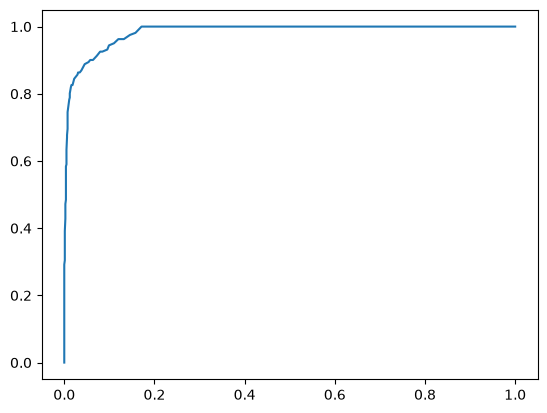

In [656]:
plt.plot(fpr, tpr, )